# **Load and Verify CSV Files**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load the Datasets
stores = pd.read_csv("dim_stores.csv")
skus = pd.read_csv("dim_skus.csv")
suppliers = pd.read_csv("dim_suppliers.csv")
events = pd.read_csv("dim_events.csv")
inventory = pd.read_csv("fact_inventory_daily.csv")

#Convert the Date Columns
events["date"] = pd.to_datetime(events["date"])
inventory["date"] = pd.to_datetime(inventory["date"])

#Display dataset sizes
print(f"stores: {stores.shape}")
print(f"skus: {skus.shape}")
print(f"suppliers: {suppliers.shape}")
print(f"events: {events.shape}")
print(f"inventory: {inventory.shape}")

stores: (12, 8)
skus: (60, 9)
suppliers: (15, 6)
events: (30, 5)
inventory: (21600, 16)


In [2]:
print("\n--- STORES ---")
display(stores.head())

print("\n--- SKUs ---")
display(skus.head())

print("\n--- SUPPLIERS ---")
display(suppliers.head())

print("\n--- EVENTS ---")
display(events.head())

print("\n--- INVENTORY ---")
display(inventory.head())


--- STORES ---


,store_id,city,city_display,city_tier,store_size,sqft,opened_year,baseline_daily_orders
0,ST01,Mumbai,Mumbai,Tier1,Large,2946,2023,580
1,ST02,Mumbai,Mumbai,Tier1,Small,1482,2024,235
2,ST03,Bengaluru,BENGALURU,Tier1,Large,3650,2022,552
3,ST04,Bengaluru,Bengaluru,Tier1,Large,4198,2025,524
4,ST05,Delhi,Delhi,Tier1,Medium,2220,2022,343



--- SKUs ---


,sku_id,sku_name,category,unit_price_inr,shelf_life_days,is_perishable,festive_relevant,popularity_tier,supplier_id
0,SKU001,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,SUP11
1,SKU002,Tomato 1kg,Fruits & Vegetables,148.76,3,Y,N,Medium,SUP08
2,SKU003,Onion 1kg,Fruits & Vegetables,66.13,3,Y,N,High,SUP01
3,SKU004,Potato 1kg,Fruits & Vegetables,51.99,5,Y,N,High,SUP01
4,SKU005,Apple 1kg,Fruits & Vegetables,145.91,5,Y,N,Medium,SUP08



--- SUPPLIERS ---


,supplier_id,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days
0,SUP01,Fresh Farms Co,Fruits & Vegetables,0.92,5,0.8
1,SUP02,Green Valley Distributors,Snacks,0.93,3,0.8
2,SUP03,Metro Dairy Supplies,Snacks,0.90,2,1.7
3,SUP04,Sunrise Agro Traders,"Beverages, Dairy",0.70,1,0.7
4,SUP05,National Snacks Ltd,Home Care,0.66,2,2.2



--- EVENTS ---


,date,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,Regular Day,none,1.0,1.0
1,2026-10-02,Regular Day,none,1.0,1.0
2,2026-10-03,Regular Day,none,1.0,1.0
3,2026-10-04,Regular Day,none,1.0,1.0
4,2026-10-05,Regular Day,none,1.0,1.0



--- INVENTORY ---


,date,store_id,sku_id,supplier_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,lead_time_days_expected,lead_time_days_actual,sales_velocity_7d,days_of_cover,is_festival_week,stockout_risk
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,1,NaN,15.00,9.66,N,Safe
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,1,NaN,12.50,10.79,N,Safe
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,1,NaN,13.33,8.99,N,Safe
3,2026-10-04,ST01,SKU001,SUP11,119.9,10,10.0,109.9,36.4,N,1,NaN,12.50,8.79,N,Safe
4,2026-10-05,ST01,SKU001,SUP11,109.9,9,9.0,100.9,36.4,N,1,NaN,11.80,8.55,N,Safe


## **Data cleaning and Validation**

In [3]:
# check missing values

print("===== STORES =====")
print(stores.isnull().sum())

print("\n===== SKUS =====")
print(skus.isnull().sum())

print("\n===== SUPPLIERS =====")
print(suppliers.isnull().sum())

print("\n===== EVENTS =====")
print(events.isnull().sum())

print("\n===== INVENTORY =====")
print(inventory.isnull().sum())

===== STORES =====
store_id                 0
city                     0
city_display             0
city_tier                0
store_size               0
sqft                     0
opened_year              0
baseline_daily_orders    0
dtype: int64

===== SKUS =====
sku_id              0
sku_name            0
category            0
unit_price_inr      0
shelf_life_days     0
is_perishable       0
festive_relevant    0
popularity_tier     0
supplier_id         0
dtype: int64

===== SUPPLIERS =====
supplier_id                0
supplier_name              0
categories_supplied        0
reliability_score          3
base_lead_time_days        0
lead_time_variance_days    0
dtype: int64

===== EVENTS =====
date                         0
event_name                   0
event_type                   0
demand_multiplier_festive    0
demand_multiplier_other      0
dtype: int64

===== INVENTORY =====
date                           0
store_id                       0
sku_id                         0
sup

In [4]:
# check duplicate records
print("Duplicate stores:", stores.duplicated().sum())
print("Duplicate SKUs:", skus.duplicated().sum())
print("Duplicate suppliers:", suppliers.duplicated().sum())
print("Duplicate events:", events.duplicated().sum())
print("Duplicate inventory rows:", inventory.duplicated().sum())

Duplicate stores: 0
Duplicate SKUs: 0
Duplicate suppliers: 0
Duplicate events: 0
Duplicate inventory rows: 0


In [5]:
#check the city issue
#print(stores[["store_id","city","city_display"]])

#clean city
stores["city_display"] = stores["city_display"].str.title()

print(stores[["store_id","city","city_display"]])

   store_id       city city_display
0      ST01     Mumbai       Mumbai
1      ST02     Mumbai       Mumbai
2      ST03  Bengaluru    Bengaluru
3      ST04  Bengaluru    Bengaluru
4      ST05      Delhi        Delhi
5      ST06      Delhi        Delhi
6      ST07       Pune         Pune
7      ST08       Pune         Pune
8      ST09  Hyderabad    Hyderabad
9      ST10  Hyderabad    Hyderabad
10     ST11    Chennai      Chennai
11     ST12    Chennai      Chennai


In [6]:
#check supplier reliability
print(suppliers["reliability_score"].unique())

print("Missing reliability values:", suppliers["reliability_score"].isnull().sum())

#convert reliability to numeric
suppliers["reliability_score"] = pd.to_numeric(suppliers["reliability_score"],errors="coerce")

print(suppliers["reliability_score"].dtype)

[0.92 0.93 0.9  0.7  0.66  nan 0.67 0.73 0.72 0.83 0.63 0.91]
Missing reliability values: 3
float64


In [7]:
#Fill the missing supplier reliability
median_reliability = suppliers["reliability_score"].median()
print("Median reliability:", median_reliability)

suppliers["reliability_score"] = suppliers["reliability_score"].fillna(median_reliability)

print("Missing reliability values:", suppliers["reliability_score"].isnull().sum())

Median reliability: 0.725
Missing reliability values: 0


In [8]:
#Check target variable
print(inventory["stockout_risk"].value_counts())

print(inventory["stockout_risk"].value_counts(normalize=True)*100)

stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64
stockout_risk
Safe        65.421296
At-Risk     24.009259
Imminent    10.569444
Name: proportion, dtype: float64


In [9]:
#check the data range
print("Start Date:",inventory["date"].min())
print("End Date:",inventory["date"].max())
print("Unique Dates:",inventory["date"].nunique())

Start Date: 2026-10-01 00:00:00
End Date: 2026-10-30 00:00:00
Unique Dates: 30


# **Join All the 5 Tables**

In [10]:
df = inventory.copy()

#merge supplier information
df = df.merge(suppliers, on="supplier_id", how="left")

#merge event information
df = df.merge(events, on="date", how="left")

#merge store information
df = df.merge(stores, on="store_id", how="left")

#merge skus information
df = df.merge(skus, on="sku_id", how="left")

In [11]:
print("Final shape:", df.shape)

print("Missing city:", df["city"].isnull().sum())
print("Missing SKU name:", df["sku_name"].isnull().sum())
print("Missing supplier name:", df["supplier_name"].isnull().sum())
print("Missing event name:", df["event_name"].isnull().sum())

Final shape: (21600, 40)
Missing city: 0
Missing SKU name: 0
Missing supplier name: 0
Missing event name: 0


# **Feature Engineering**

In [12]:
print(df.columns.tolist())

['date', 'store_id', 'sku_id', 'supplier_id_x', 'opening_stock', 'units_demanded', 'units_sold', 'closing_stock', 'reorder_point', 'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual', 'sales_velocity_7d', 'days_of_cover', 'is_festival_week', 'stockout_risk', 'supplier_name', 'categories_supplied', 'reliability_score', 'base_lead_time_days', 'lead_time_variance_days', 'event_name', 'event_type', 'demand_multiplier_festive', 'demand_multiplier_other', 'city', 'city_display', 'city_tier', 'store_size', 'sqft', 'opened_year', 'baseline_daily_orders', 'sku_name', 'category', 'unit_price_inr', 'shelf_life_days', 'is_perishable', 'festive_relevant', 'popularity_tier', 'supplier_id_y']


In [13]:
#reorder_gap
df["reorder_gap"] = (df["reorder_point"] - df["closing_stock"])

#days_of_cover_ratio
df["days_of_cover_ratio"] = (df["days_of_cover"] / df["lead_time_days_expected"])

#Festival timing features
df["day_of_month"] = df["date"].dt.day
festival_start = pd.Timestamp("2026-10-22")
df["days_festival_start"] = (df["date"] - festival_start).dt.days
df.loc[df["date"] < festival_start, "days_festival_start"] = -1

#recent_reorder
df = df.sort_values(["store_id","sku_id","date"]).reset_index(drop=True)

df["recent_reorder"] = (df.groupby(["store_id","sku_id"])["reorder_placed"].shift(1))
df["recent_reorder"] = (df["recent_reorder"].map({"Yes":1,"No":0}).fillna(0))

In [14]:
new_features = ["reorder_gap","days_of_cover_ratio","day_of_month","days_festival_start","recent_reorder"]
display(df[new_features].head(10))
print("New number of columns:", df.shape[1])

,reorder_gap,days_of_cover_ratio,day_of_month,days_festival_start,recent_reorder
0,-108.5,9.66,1,-1,0.0
1,-98.5,10.79,2,-1,0.0
2,-83.5,8.99,3,-1,0.0
3,-73.5,8.79,4,-1,0.0
4,-64.5,8.55,5,-1,0.0
5,-52.5,7.52,6,-1,0.0
6,-43.5,6.99,7,-1,0.0
7,-30.5,6.01,8,-1,0.0
8,-18.5,4.81,9,-1,0.0
9,-5.5,3.76,10,-1,0.0


New number of columns: 45


# **Exploratory Data Analysis**

In [15]:
#stockout risk distribution
print(df["stockout_risk"].value_counts())

stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64


In [16]:
risk_percentage = (df["stockout_risk"].value_counts(normalize=True).mul(100).round(2))
print(risk_percentage)

stockout_risk
Safe        65.42
At-Risk     24.01
Imminent    10.57
Name: proportion, dtype: float64


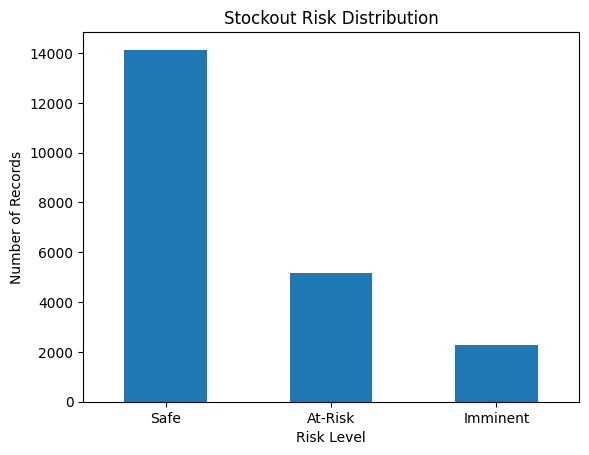

In [17]:
#plot the risk distribution
df["stockout_risk"].value_counts().plot(kind="bar")
plt.title("Stockout Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

In [18]:
#Festival Week vs Stockout Risk
festival_risk = pd.crosstab(df["is_festival_week"],df["stockout_risk"],normalize="index")*100
print(festival_risk.round(2))

stockout_risk     At-Risk  Imminent   Safe
is_festival_week                          
N                   24.19      9.51  66.30
Y                   21.80     23.31  54.89


In [19]:
#supplier reliability

def reliability_group(x):
  if x < 0.75:
    return "Low"
  elif x < 0.85:
    return "Medium"
  else:
    return "High"

df["supplier_reliability_group"] = (df["reliability_score"].apply(reliability_group))

In [20]:
supplier_risk = pd.crosstab(df["supplier_reliability_group"],df["stockout_risk"],normalize="index")*100
print(supplier_risk.round(2))

stockout_risk               At-Risk  Imminent   Safe
supplier_reliability_group                          
High                          34.88      3.82  61.30
Low                           21.63     13.07  65.30
Medium                        17.57      3.26  79.17


In [21]:
perishable_risk = pd.crosstab(df["is_perishable"],df["stockout_risk"],normalize="index")*100
print(perishable_risk.round(2))

stockout_risk  At-Risk  Imminent   Safe
is_perishable                          
N                24.64      9.30  66.06
Y                22.92     12.77  64.32


In [22]:
category_risk = pd.crosstab(df["category"],df["stockout_risk"],normalize="index")*100
print(category_risk.round(2))

stockout_risk        At-Risk  Imminent   Safe
category                                     
Bakery                 26.34     26.11  47.55
Beverages              22.08     14.55  63.37
Dairy                  14.48      7.54  77.98
Fruits & Vegetables    27.19      7.93  64.88
Home Care              20.60      8.52  70.88
Personal Care          19.17      6.79  74.05
Snacks                 28.98     10.19  60.83
Staples                30.14      5.83  64.03


In [23]:
category_risk_sorted = category_risk.sort_values("Imminent",ascending=False)
print(category_risk_sorted.round(2))

stockout_risk        At-Risk  Imminent   Safe
category                                     
Bakery                 26.34     26.11  47.55
Beverages              22.08     14.55  63.37
Snacks                 28.98     10.19  60.83
Home Care              20.60      8.52  70.88
Fruits & Vegetables    27.19      7.93  64.88
Dairy                  14.48      7.54  77.98
Personal Care          19.17      6.79  74.05
Staples                30.14      5.83  64.03


In [24]:
#days of cover vs stockout risk
cover_analysis = (df.groupby("stockout_risk")["days_of_cover"].agg([
    "count","mean","min","max","median"
]).round(2))
print(cover_analysis)

               count   mean  min     max  median
stockout_risk                                   
At-Risk         5186   4.05  1.0    8.80    3.82
Imminent        2283   1.95  0.0    7.88    1.72
Safe           14131  10.64  4.0  134.85   10.05


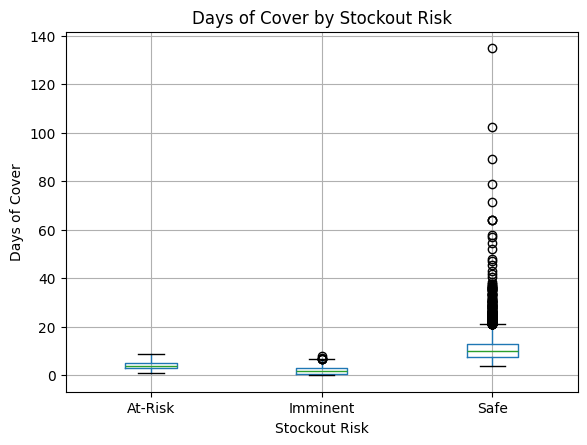

In [25]:
df.boxplot(column="days_of_cover",by="stockout_risk")
plt.title("Days of Cover by Stockout Risk")
plt.suptitle("")
plt.xlabel("Stockout Risk")
plt.ylabel("Days of Cover")
plt.show()

# **Prepare Data for Machine Learning**

In [26]:
y = df["stockout_risk"]

feature_columns = [
    # Inventory / demand
    "opening_stock",
    "units_demanded",
    "units_sold",
    "closing_stock",
    "reorder_point",
    "reorder_placed",
    "lead_time_days_expected",
    "sales_velocity_7d",
    "days_of_cover",
    "reorder_gap",
    "days_of_cover_ratio",
    "recent_reorder",

    # Supplier
    "reliability_score",
    "base_lead_time_days",
    "lead_time_variance_days",

    # Calendar / event
    "is_festival_week",
    "event_type",
    "demand_multiplier_festive",
    "demand_multiplier_other",
    "day_of_month",
    "days_festival_start",

    # Store
    "city",
    "store_size",
    "sqft",
    "opened_year",
    "baseline_daily_orders",

    # Product
    "category",
    "unit_price_inr",
    "shelf_life_days",
    "is_perishable",
    "festive_relevant",
    "popularity_tier",

    # Supplier reliability category
    "supplier_reliability_group"
]

X = df[feature_columns].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

# Convert Y/N columns to 1/0
yn_columns = [
    "reorder_placed",
    "is_festival_week",
    "is_perishable",
    "festive_relevant"
]

for col in yn_columns:
    X[col] = X[col].map({
        "Y": 1,
        "N": 0
    })

# Check the result
print(X[yn_columns].head())

X shape: (21600, 33)
y shape: (21600,)
   reorder_placed  is_festival_week  is_perishable  festive_relevant
0               0                 0              1                 0
1               0                 0              1                 0
2               0                 0              1                 0
3               0                 0              1                 0
4               0                 0              1                 0


In [27]:
print("Missing values in these columns:")
print(X[yn_columns].isnull().sum())

Missing values in these columns:
reorder_placed      0
is_festival_week    0
is_perishable       0
festive_relevant    0
dtype: int64


In [28]:
categorical_columns = [
    "event_type",
    "city",
    "store_size",
    "category",
    "popularity_tier",
    "supplier_reliability_group"]

X = pd.get_dummies(X,columns=categorical_columns,drop_first=False)
print("X shape after encoding:", X.shape)

X shape after encoding: (21600, 53)


In [29]:
X = X.astype(float)

print("All values are numeric:",X.dtypes.apply(lambda x: x.kind in "biufc").all())

print("Total missing values in X:",X.isnull().sum().sum())

All values are numeric: True
Total missing values in X: 0


In [30]:
#time-based train/test split
train_mask = df["date"] <= pd.Timestamp("2026-10-23")
test_mask = df["date"] >= pd.Timestamp("2026-10-24")

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16560, 53)
X_test shape: (5040, 53)
y_train shape: (16560,)
y_test shape: (5040,)


In [31]:
#verify dates
print("Training:",df.loc[train_mask,"date"].min(),"to",df.loc[train_mask,"date"].max())
print("Testing:",df.loc[test_mask,"date"].min(),"to",df.loc[test_mask,"date"].max())

#verify thaat there is no overlap
print("Train/Test overlap:",set(df.loc[train_mask,"date"]).intersection(set(df.loc[test_mask,"date"])))

Training: 2026-10-01 00:00:00 to 2026-10-23 00:00:00
Testing: 2026-10-24 00:00:00 to 2026-10-30 00:00:00
Train/Test overlap: set()


# **Train the Machine Learning Models**

In [32]:
from sklearn.metrics import (accuracy_score,f1_score,recall_score,classification_report,confusion_matrix)

# Find the most common class
majority_class = y_train.mode()[0]

y_pred_baseline = [majority_class] * len(y_test)

baseline_accuracy = accuracy_score(y_test,y_pred_baseline)
baseline_f1 = f1_score(y_test,y_pred_baseline,average="macro")
baseline_imminent_recall = recall_score(y_test,y_pred_baseline,labels=["Imminent"],average=None)[0]

print("Majority class:", majority_class)
print("Baseline Accuracy:",round(baseline_accuracy, 4))
print("Baseline Macro F1:",round(baseline_f1, 4))
print("Baseline Imminent Recall:",round(baseline_imminent_recall, 4))

Majority class: Safe
Baseline Accuracy: 0.6228
Baseline Macro F1: 0.2559
Baseline Imminent Recall: 0.0


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(max_iter=2000,class_weight="balanced",random_state=42)
logistic_model.fit(X_train_scaled,y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

logistic_accuracy = accuracy_score(y_test,y_pred_logistic)
logistic_f1 = f1_score(y_test,y_pred_logistic,average="macro")
logistic_imminent_recall = recall_score(y_test,y_pred_logistic,labels=["Imminent"],average=None)[0]

print("Logistic Regression Accuracy:",round(logistic_accuracy, 4))
print("Logistic Regression Macro F1:",round(logistic_f1, 4))
print("Logistic Regression Imminent Recall:",round(logistic_imminent_recall, 4))

Logistic Regression Accuracy: 0.9006
Logistic Regression Macro F1: 0.8285
Logistic Regression Imminent Recall: 0.9819


In [34]:
print(classification_report(y_test,y_pred_logistic,zero_division=0))

              precision    recall  f1-score   support

     At-Risk       0.96      0.58      0.72      1126
    Imminent       0.63      0.98      0.77       775
        Safe       0.99      0.99      0.99      3139

    accuracy                           0.90      5040
   macro avg       0.86      0.85      0.83      5040
weighted avg       0.93      0.90      0.90      5040



In [35]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1)

random_forest.fit(X_train,y_train)

y_pred_rf = random_forest.predict(X_test)

rf_accuracy = accuracy_score(y_test,y_pred_rf)
rf_f1 = f1_score(y_test,y_pred_rf,average="macro")
rf_imminent_recall = recall_score(y_test,y_pred_rf,labels=["Imminent"],average=None)[0]

print("Random Forest Accuracy:",round(rf_accuracy, 4))
print("Random Forest Macro F1:",round(rf_f1, 4))
print("Random Forest Imminent Recall:",round(rf_imminent_recall, 4))

Random Forest Accuracy: 0.9304
Random Forest Macro F1: 0.8659
Random Forest Imminent Recall: 0.6284


In [36]:
print(classification_report(y_test,y_pred_rf,zero_division=0))

              precision    recall  f1-score   support

     At-Risk       0.78      0.95      0.86      1126
    Imminent       0.90      0.63      0.74       775
        Safe       1.00      1.00      1.00      3139

    accuracy                           0.93      5040
   macro avg       0.89      0.86      0.87      5040
weighted avg       0.94      0.93      0.93      5040



In [37]:
#model comparison table

model_comparison = pd.DataFrame({
    "Model": ["Majority Baseline", "Logistic Regression", "Random Forest"],
    "Accuracy": [baseline_accuracy, logistic_accuracy, rf_accuracy],
    "Macro F1": [baseline_f1, logistic_f1, rf_f1],
    "Imminent Recall": [baseline_imminent_recall, logistic_imminent_recall, rf_imminent_recall]
})

print(model_comparison.round(4).to_string(index=False))

              Model  Accuracy  Macro F1  Imminent Recall
  Majority Baseline    0.6228    0.2559           0.0000
Logistic Regression    0.9006    0.8285           0.9819
      Random Forest    0.9304    0.8659           0.6284


In [41]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic,
    labels=["Safe", "At-Risk", "Imminent"])

In [42]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["Safe", "At-Risk", "Imminent"])


In [43]:
print("Labels: Safe, At-Risk, Imminent")

print("\nLogistic Regression:")
print(cm_logistic)

print("\nRandom Forest:")
print(cm_rf)

Labels: Safe, At-Risk, Imminent

Logistic Regression:
[[3123   16    0]
 [  28  655  443]
 [   0   14  761]]

Random Forest:
[[3134    5    0]
 [   4 1068   54]
 [   0  288  487]]


# **Final Model and Business Output**

In [63]:
final_model = logistic_model

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": np.abs(
        final_model.coef_
    ).mean(axis=0)
})

feature_importance = feature_importance.sort_values("Importance",
ascending=False)

print(feature_importance.head(15).to_string(index=False))

                Feature  Importance
          days_of_cover    6.877044
    days_of_cover_ratio    5.554624
            reorder_gap    0.777353
         units_demanded    0.747984
lead_time_days_expected    0.699214
    base_lead_time_days    0.699214
             units_sold    0.674684
      sales_velocity_7d    0.656201
          opening_stock    0.559875
  baseline_daily_orders    0.527924
          closing_stock    0.498268
       store_size_Small    0.336094
       store_size_Large    0.326882
         reorder_placed    0.292368
      reliability_score    0.279699


In [46]:
final_results = df.loc[test_mask].copy()
final_results["predicted_stockout_risk"] = (y_pred_logistic)

print(
    final_results[
        [
            "date",
            "store_id",
            "sku_id",
            "category",
            "days_of_cover",
            "stockout_risk",
            "predicted_stockout_risk"
        ]
    ].head(20)
)

         date store_id  sku_id             category  days_of_cover  \
23 2026-10-24     ST01  SKU001  Fruits & Vegetables           2.77   
24 2026-10-25     ST01  SKU001  Fruits & Vegetables          14.36   
25 2026-10-26     ST01  SKU001  Fruits & Vegetables          10.65   
26 2026-10-27     ST01  SKU001  Fruits & Vegetables           8.98   
27 2026-10-28     ST01  SKU001  Fruits & Vegetables           7.50   
28 2026-10-29     ST01  SKU001  Fruits & Vegetables           6.31   
29 2026-10-30     ST01  SKU001  Fruits & Vegetables           5.68   
53 2026-10-24     ST01  SKU002  Fruits & Vegetables           2.31   
54 2026-10-25     ST01  SKU002  Fruits & Vegetables           0.93   
55 2026-10-26     ST01  SKU002  Fruits & Vegetables          13.12   
56 2026-10-27     ST01  SKU002  Fruits & Vegetables          12.72   
57 2026-10-28     ST01  SKU002  Fruits & Vegetables          11.02   
58 2026-10-29     ST01  SKU002  Fruits & Vegetables          10.59   
59 2026-10-30     ST

In [54]:
imminent_predictions = final_results[final_results["predicted_stockout_risk"] == "Imminent"].copy()

print(
    imminent_predictions[
        [
            "date",
            "store_id",
            "sku_id",
            "sku_name",
            "category",
            "days_of_cover",
            "reorder_point",
            "reorder_placed",
            "supplier_name",
            "predicted_stockout_risk"
        ]].head(20))

print(final_results["predicted_stockout_risk"].value_counts())

          date store_id  sku_id          sku_name             category  \
53  2026-10-24     ST01  SKU002        Tomato 1kg  Fruits & Vegetables   
54  2026-10-25     ST01  SKU002        Tomato 1kg  Fruits & Vegetables   
87  2026-10-28     ST01  SKU003         Onion 1kg  Fruits & Vegetables   
118 2026-10-29     ST01  SKU004        Potato 1kg  Fruits & Vegetables   
119 2026-10-30     ST01  SKU004        Potato 1kg  Fruits & Vegetables   
179 2026-10-30     ST01  SKU006      Spinach 250g  Fruits & Vegetables   
203 2026-10-24     ST01  SKU007     Cucumber 500g  Fruits & Vegetables   
204 2026-10-25     ST01  SKU007     Cucumber 500g  Fruits & Vegetables   
263 2026-10-24     ST01  SKU009     Capsicum 500g  Fruits & Vegetables   
264 2026-10-25     ST01  SKU009     Capsicum 500g  Fruits & Vegetables   
329 2026-10-30     ST01  SKU011         Curd 400g                Dairy   
449 2026-10-30     ST01  SKU015        Ghee 500ml                Dairy   
473 2026-10-24     ST01  SKU016     Bu

In [57]:
#create priority alerts

priority_alerts = (imminent_predictions.sort_values(
        ["days_of_cover", "date"])
    .groupby(
        ["store_id", "sku_id", "sku_name", "category"],
        as_index=False)
    .agg(
        min_days_of_cover=("days_of_cover", "min"),
        latest_date=("date", "max"),
        reorder_point=("reorder_point", "first"),
        supplier_name=("supplier_name", "first"),
        reorder_placed=("reorder_placed", "last")
        ))

#sort by urgency
priority_alerts = priority_alerts.sort_values("min_days_of_cover")

print(priority_alerts.head(20).to_string(index=False))

store_id sku_id             sku_name            category  min_days_of_cover latest_date  reorder_point             supplier_name reorder_placed
    ST12 SKU060        Croissant 2pc              Bakery                0.0  2026-10-24          142.8        Daily Bakes Supply              N
    ST12 SKU023          Popcorn 70g              Snacks                0.0  2026-10-27           21.0      Golden Grain Traders              N
    ST01 SKU058        Cup Cakes 4pc              Bakery                0.0  2026-10-25          146.9         Bharat Staples Co              N
    ST02 SKU005            Apple 1kg Fruits & Vegetables                0.0  2026-10-25           17.1        HomeShine Supplies              N
    ST08 SKU059      Rusk Toast 200g              Bakery                0.0  2026-10-26           83.0         Bharat Staples Co              N
    ST08 SKU058        Cup Cakes 4pc              Bakery                0.0  2026-10-26           37.6         Bharat Staples Co        

In [59]:
#add an urgency level
def urgency(days):
    if days <= 0:
        return "CRITICAL"
    elif days <= 1:
        return "HIGH"
    elif days <= 3:
        return "MEDIUM"
    else:
        return "LOW"

priority_alerts["urgency"] = (priority_alerts["min_days_of_cover"].apply(urgency))

priority_alerts["urgency_rank"] = (
    priority_alerts["urgency"]
    .map({
        "CRITICAL": 1,
        "HIGH": 2,
        "MEDIUM": 3,
        "LOW": 4
    })
)

priority_alerts = priority_alerts.sort_values(["urgency_rank", "min_days_of_cover"])

In [60]:
print(
    priority_alerts[
        [
            "urgency",
            "store_id",
            "sku_id",
            "sku_name",
            "category",
            "min_days_of_cover",
            "reorder_point",
            "reorder_placed",
            "supplier_name"
        ]
    ].head(20).to_string(index=False)
)

 urgency store_id sku_id             sku_name            category  min_days_of_cover  reorder_point reorder_placed             supplier_name
CRITICAL     ST12 SKU060        Croissant 2pc              Bakery                0.0          142.8              N        Daily Bakes Supply
CRITICAL     ST12 SKU023          Popcorn 70g              Snacks                0.0           21.0              N      Golden Grain Traders
CRITICAL     ST01 SKU058        Cup Cakes 4pc              Bakery                0.0          146.9              N         Bharat Staples Co
CRITICAL     ST02 SKU005            Apple 1kg Fruits & Vegetables                0.0           17.1              N        HomeShine Supplies
CRITICAL     ST08 SKU059      Rusk Toast 200g              Bakery                0.0           83.0              N         Bharat Staples Co
CRITICAL     ST08 SKU058        Cup Cakes 4pc              Bakery                0.0           37.6              N         Bharat Staples Co
CRITICAL     

In [68]:
#simple business recommendation
def recommendation(row):

    if row["min_days_of_cover"] <= 0:

        if row["reorder_placed"] == "Y":
            return "CRITICAL: Stock depleted. Reorder already placed — expedite replenishment."

        else:
            return "URGENT: Stock depleted. Reorder immediately."

    elif row["min_days_of_cover"] <= 1:

        if row["reorder_placed"] == "Y":
            return "HIGH: Very low stock. Reorder placed — monitor delivery."

        else:
            return "HIGH PRIORITY: Reorder immediately."

    elif row["min_days_of_cover"] <= 3:

        if row["reorder_placed"] == "Y":
            return "MEDIUM: Low stock. Reorder placed — monitor replenishment."

        else:
            return "MEDIUM: Monitor closely and initiate reorder."

    else:
        return "LOW: Monitor inventory."

priority_alerts["recommendation"] = (
    priority_alerts.apply(
        recommendation,
        axis=1
    )
)

print(
    priority_alerts[
        [
            "urgency",
            "store_id",
            "sku_name",
            "min_days_of_cover",
            "supplier_name",
            "recommendation"
        ]
    ].head(20).to_string(index=False)
)

 urgency store_id             sku_name  min_days_of_cover             supplier_name                                                             recommendation
CRITICAL     ST12        Croissant 2pc                0.0        Daily Bakes Supply                               URGENT: Stock depleted. Reorder immediately.
CRITICAL     ST12          Popcorn 70g                0.0      Golden Grain Traders                               URGENT: Stock depleted. Reorder immediately.
CRITICAL     ST01        Cup Cakes 4pc                0.0         Bharat Staples Co                               URGENT: Stock depleted. Reorder immediately.
CRITICAL     ST02            Apple 1kg                0.0        HomeShine Supplies                               URGENT: Stock depleted. Reorder immediately.
CRITICAL     ST08      Rusk Toast 200g                0.0         Bharat Staples Co                               URGENT: Stock depleted. Reorder immediately.
CRITICAL     ST08        Cup Cakes 4pc        

In [66]:
# Overall predicted risk summary
risk_summary = (
    final_results["predicted_stockout_risk"]
    .value_counts()
    .rename_axis("Risk Level")
    .reset_index(name="Count")
)

risk_summary["Percentage"] = (
    risk_summary["Count"]
    / risk_summary["Count"].sum()
    * 100
)

print(risk_summary)

actual_vs_predicted = pd.crosstab(
    final_results["stockout_risk"],
    final_results["predicted_stockout_risk"]
)

print(actual_vs_predicted)

top_alerts = priority_alerts[
    [
        "urgency",
        "store_id",
        "sku_id",
        "sku_name",
        "category",
        "min_days_of_cover",
        "reorder_point",
        "reorder_placed",
        "supplier_name",
        "recommendation"
    ]
].head(20)

print(top_alerts.to_string(index=False))

  Risk Level  Count  Percentage
0       Safe   3151   62.519841
1   Imminent   1204   23.888889
2    At-Risk    685   13.591270
predicted_stockout_risk  At-Risk  Imminent  Safe
stockout_risk                                   
At-Risk                      655       443    28
Imminent                      14       761     0
Safe                          16         0  3123
 urgency store_id sku_id             sku_name            category  min_days_of_cover  reorder_point reorder_placed             supplier_name                               recommendation
CRITICAL     ST12 SKU060        Croissant 2pc              Bakery                0.0          142.8              N        Daily Bakes Supply URGENT: Stock depleted. Reorder immediately.
CRITICAL     ST12 SKU023          Popcorn 70g              Snacks                0.0           21.0              N      Golden Grain Traders URGENT: Stock depleted. Reorder immediately.
CRITICAL     ST01 SKU058        Cup Cakes 4pc              Bakery    

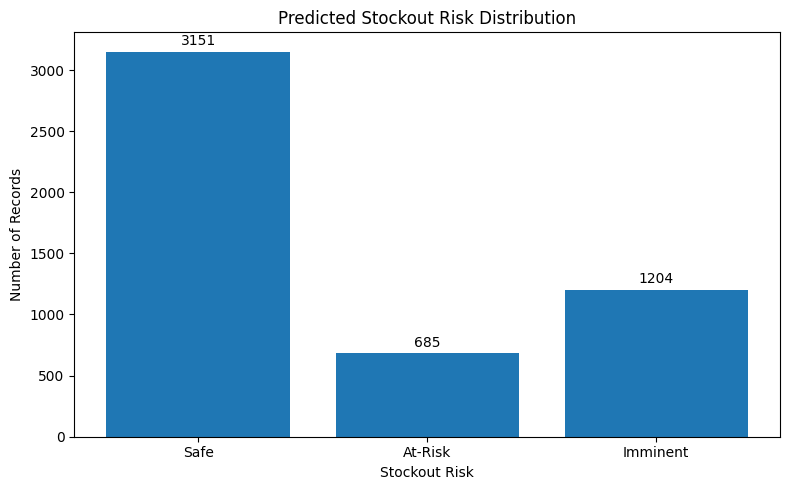

In [69]:
#risk distribution visualization

risk_counts = (
    final_results["predicted_stockout_risk"]
    .value_counts()
    .reindex(["Safe", "At-Risk", "Imminent"])
)

plt.figure(figsize=(8, 5))
plt.bar(risk_counts.index, risk_counts.values)

plt.title("Predicted Stockout Risk Distribution")
plt.xlabel("Stockout Risk")
plt.ylabel("Number of Records")

for i, value in enumerate(risk_counts.values):
    plt.text(i, value + 50, str(value), ha="center")

plt.tight_layout()
plt.show()

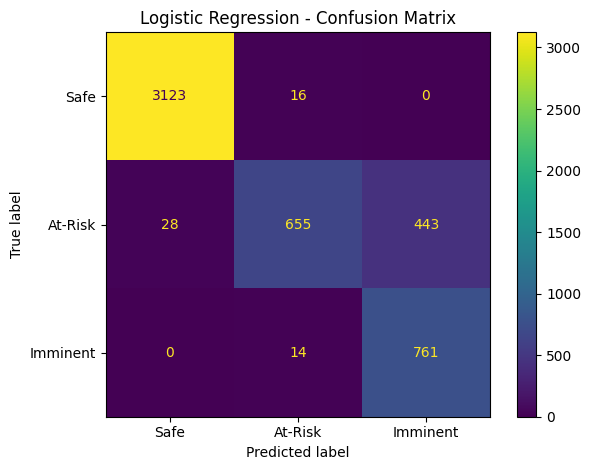

In [71]:
#confusion matrix visualization
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    labels=["Safe", "At-Risk", "Imminent"],
    values_format="d"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

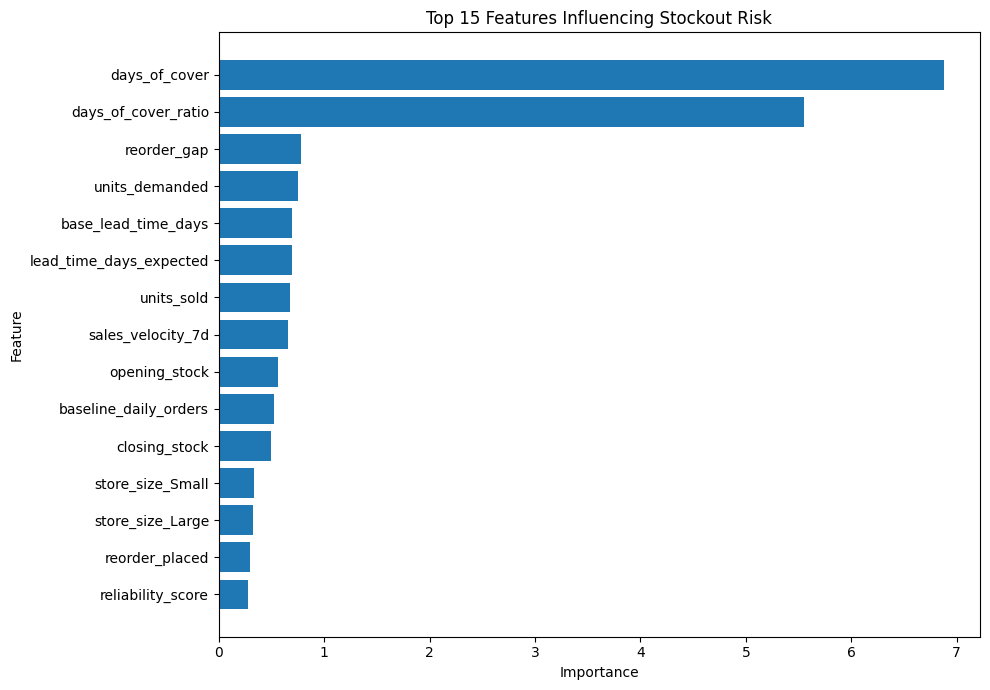

In [72]:
#feature importance visualization

top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features Influencing Stockout Risk")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

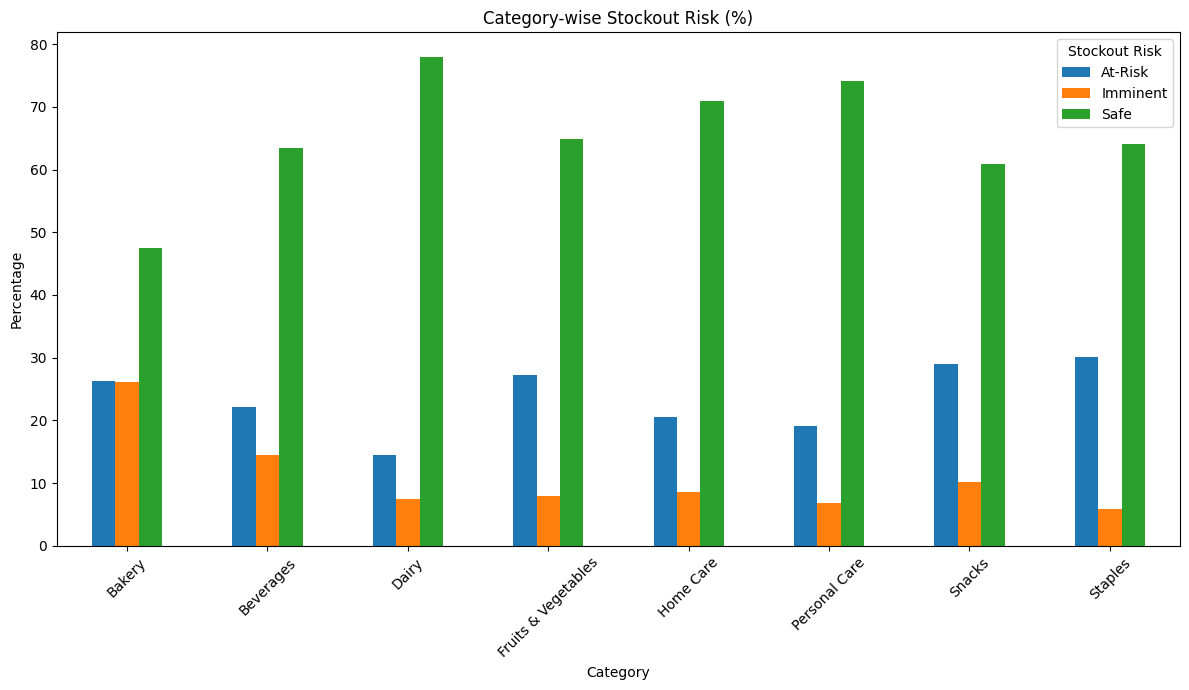

In [74]:
category_risk_pct = pd.crosstab(
    df["category"],
    df["stockout_risk"],
    normalize="index"
) * 100

category_risk_pct.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Category-wise Stockout Risk (%)")
plt.xlabel("Category")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Stockout Risk")
plt.tight_layout()
plt.show()

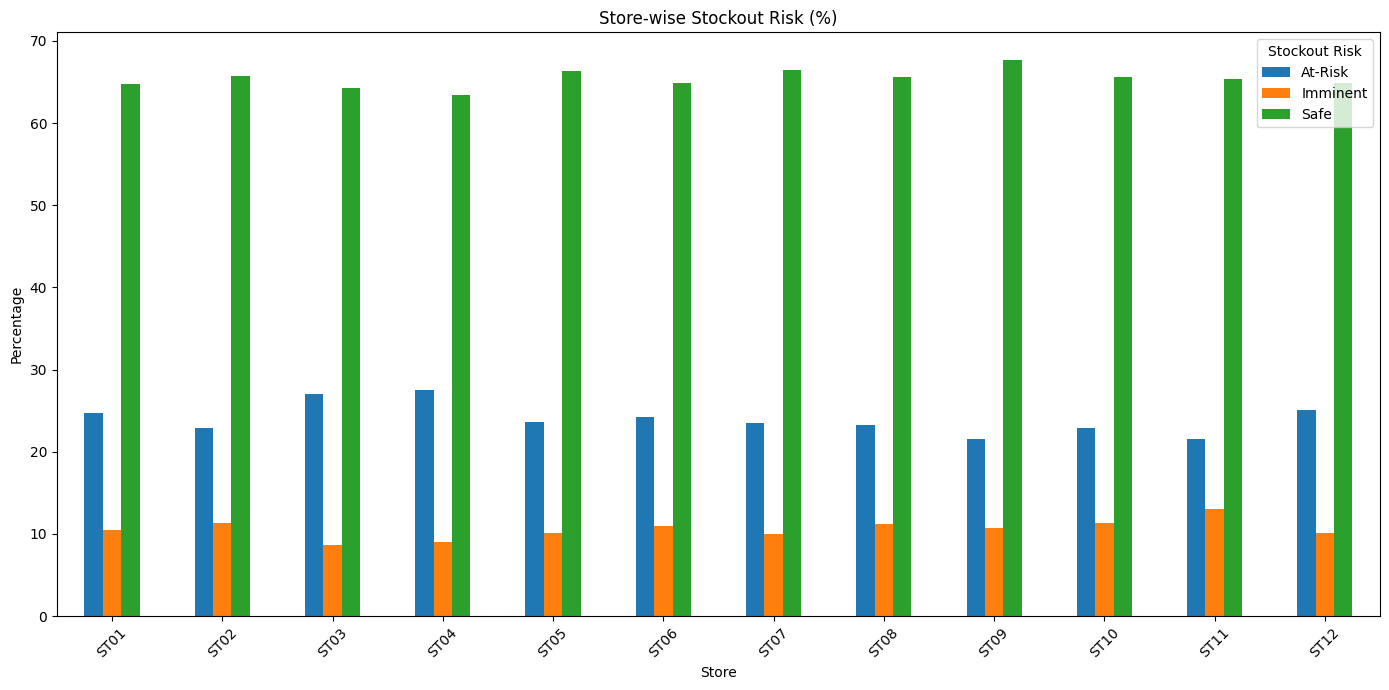

In [80]:
#Store-wise risk percentage

store_risk_pct = pd.crosstab(
    df["store_id"],
    df["stockout_risk"],
    normalize="index"
) * 100

store_risk_pct.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Store-wise Stockout Risk (%)")
plt.xlabel("Store")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Stockout Risk")
plt.tight_layout()
plt.show()

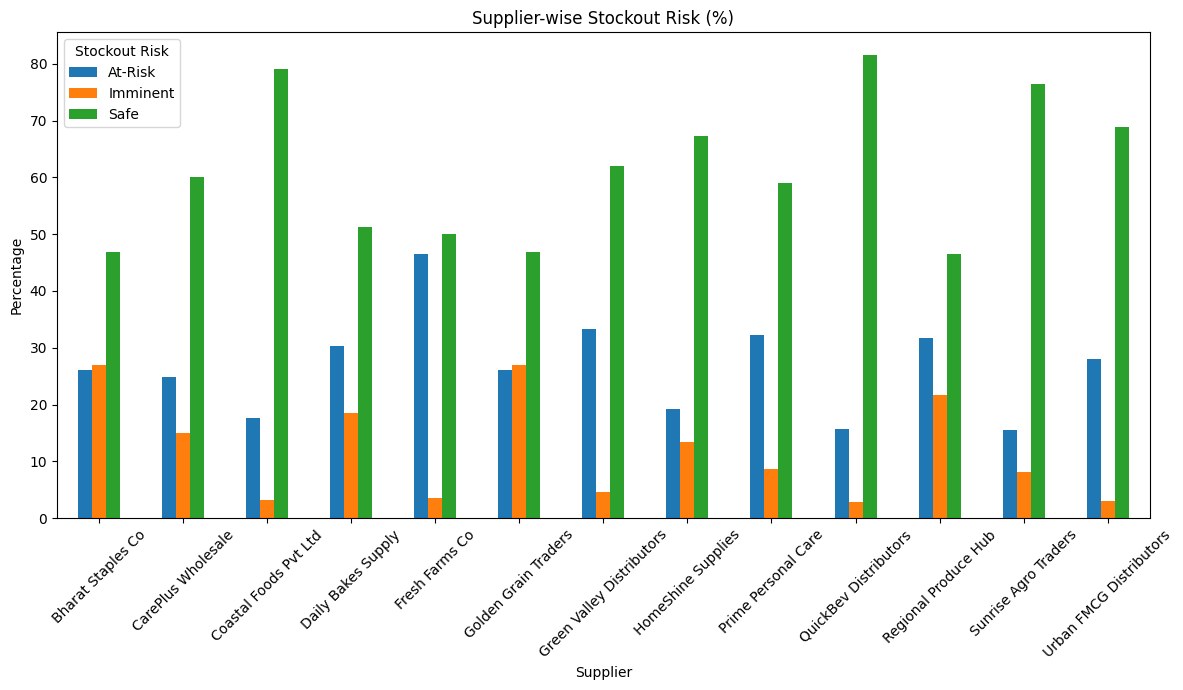

In [77]:
#Supplier Risk percentage Analysis

supplier_risk_pct = pd.crosstab(
    df["supplier_name"],
    df["stockout_risk"],
    normalize="index"
) * 100

supplier_risk_pct.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Supplier-wise Stockout Risk (%)")
plt.xlabel("Supplier")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Stockout Risk")
plt.tight_layout()
plt.show()

In [78]:
highest_risk_suppliers = supplier_risk_pct.sort_values(
    "At-Risk",
    ascending=False
)

print("Suppliers with Highest At-Risk Percentage:")
print(highest_risk_suppliers[["At-Risk"]].round(2))

Suppliers with Highest At-Risk Percentage:
stockout_risk              At-Risk
supplier_name                     
Fresh Farms Co               46.48
Green Valley Distributors    33.39
Prime Personal Care          32.22
Regional Produce Hub         31.81
Daily Bakes Supply           30.28
Urban FMCG Distributors      28.06
Golden Grain Traders         26.11
Bharat Staples Co            26.02
CarePlus Wholesale           24.91
HomeShine Supplies           19.24
Coastal Foods Pvt Ltd        17.57
QuickBev Distributors        15.73
Sunrise Agro Traders         15.56


Top 20 Critical Stockout Alerts:
      date store_id sku_id            category stockout_risk  days_of_cover  units_demanded  units_sold  reorder_point
2026-10-09     ST01 SKU005 Fruits & Vegetables      Imminent            0.0              35        29.0           97.0
2026-10-23     ST01 SKU005 Fruits & Vegetables      Imminent            0.0              23         5.3           97.0
2026-10-25     ST01 SKU007 Fruits & Vegetables      Imminent            0.0              57        36.4          223.0
2026-10-25     ST01 SKU009 Fruits & Vegetables      Imminent            0.0              44        41.6          138.2
2026-10-22     ST01 SKU013               Dairy      Imminent            0.0              52        22.4          183.8
2026-10-23     ST01 SKU014               Dairy      Imminent            0.0              54         9.8          133.5
2026-10-26     ST01 SKU016               Dairy      Imminent            0.0              32         1.0           86.6
2026-10-27     

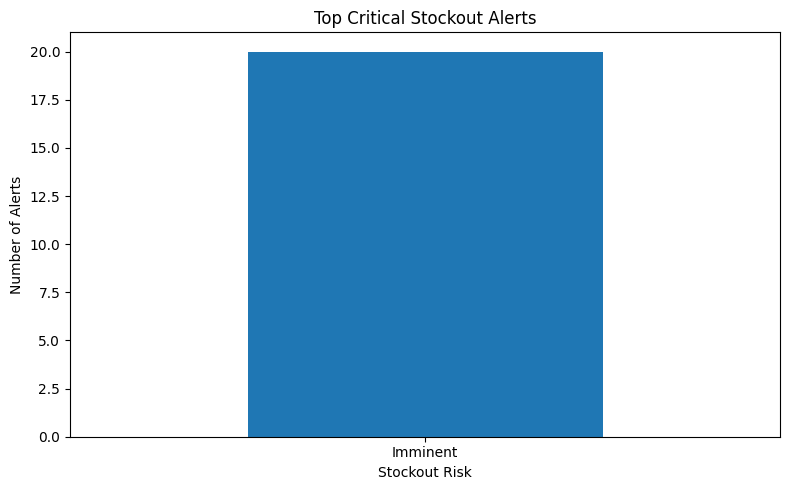

In [82]:
# Top Critical Alerts

risk_priority = {
    "Imminent": 2,
    "At-Risk": 1,
    "Safe": 0
}

df["risk_priority"] = df["stockout_risk"].map(risk_priority)

top_alerts = df.sort_values(
    ["risk_priority", "days_of_cover"],
    ascending=[False, True]
).head(20)

print("Top 20 Critical Stockout Alerts:")

print(
    top_alerts[
        [
            "date",
            "store_id",
            "sku_id",
            "category",
            "stockout_risk",
            "days_of_cover",
            "units_demanded",
            "units_sold",
            "reorder_point"
        ]
    ].to_string(index=False)
)

alert_counts = top_alerts["stockout_risk"].value_counts()

alert_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Top Critical Stockout Alerts")
plt.xlabel("Stockout Risk")
plt.ylabel("Number of Alerts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()